# Artin Tavasoli 
**SID : 810102543**

## Object Dectection Using Sparse R-CNN

---

### Overview

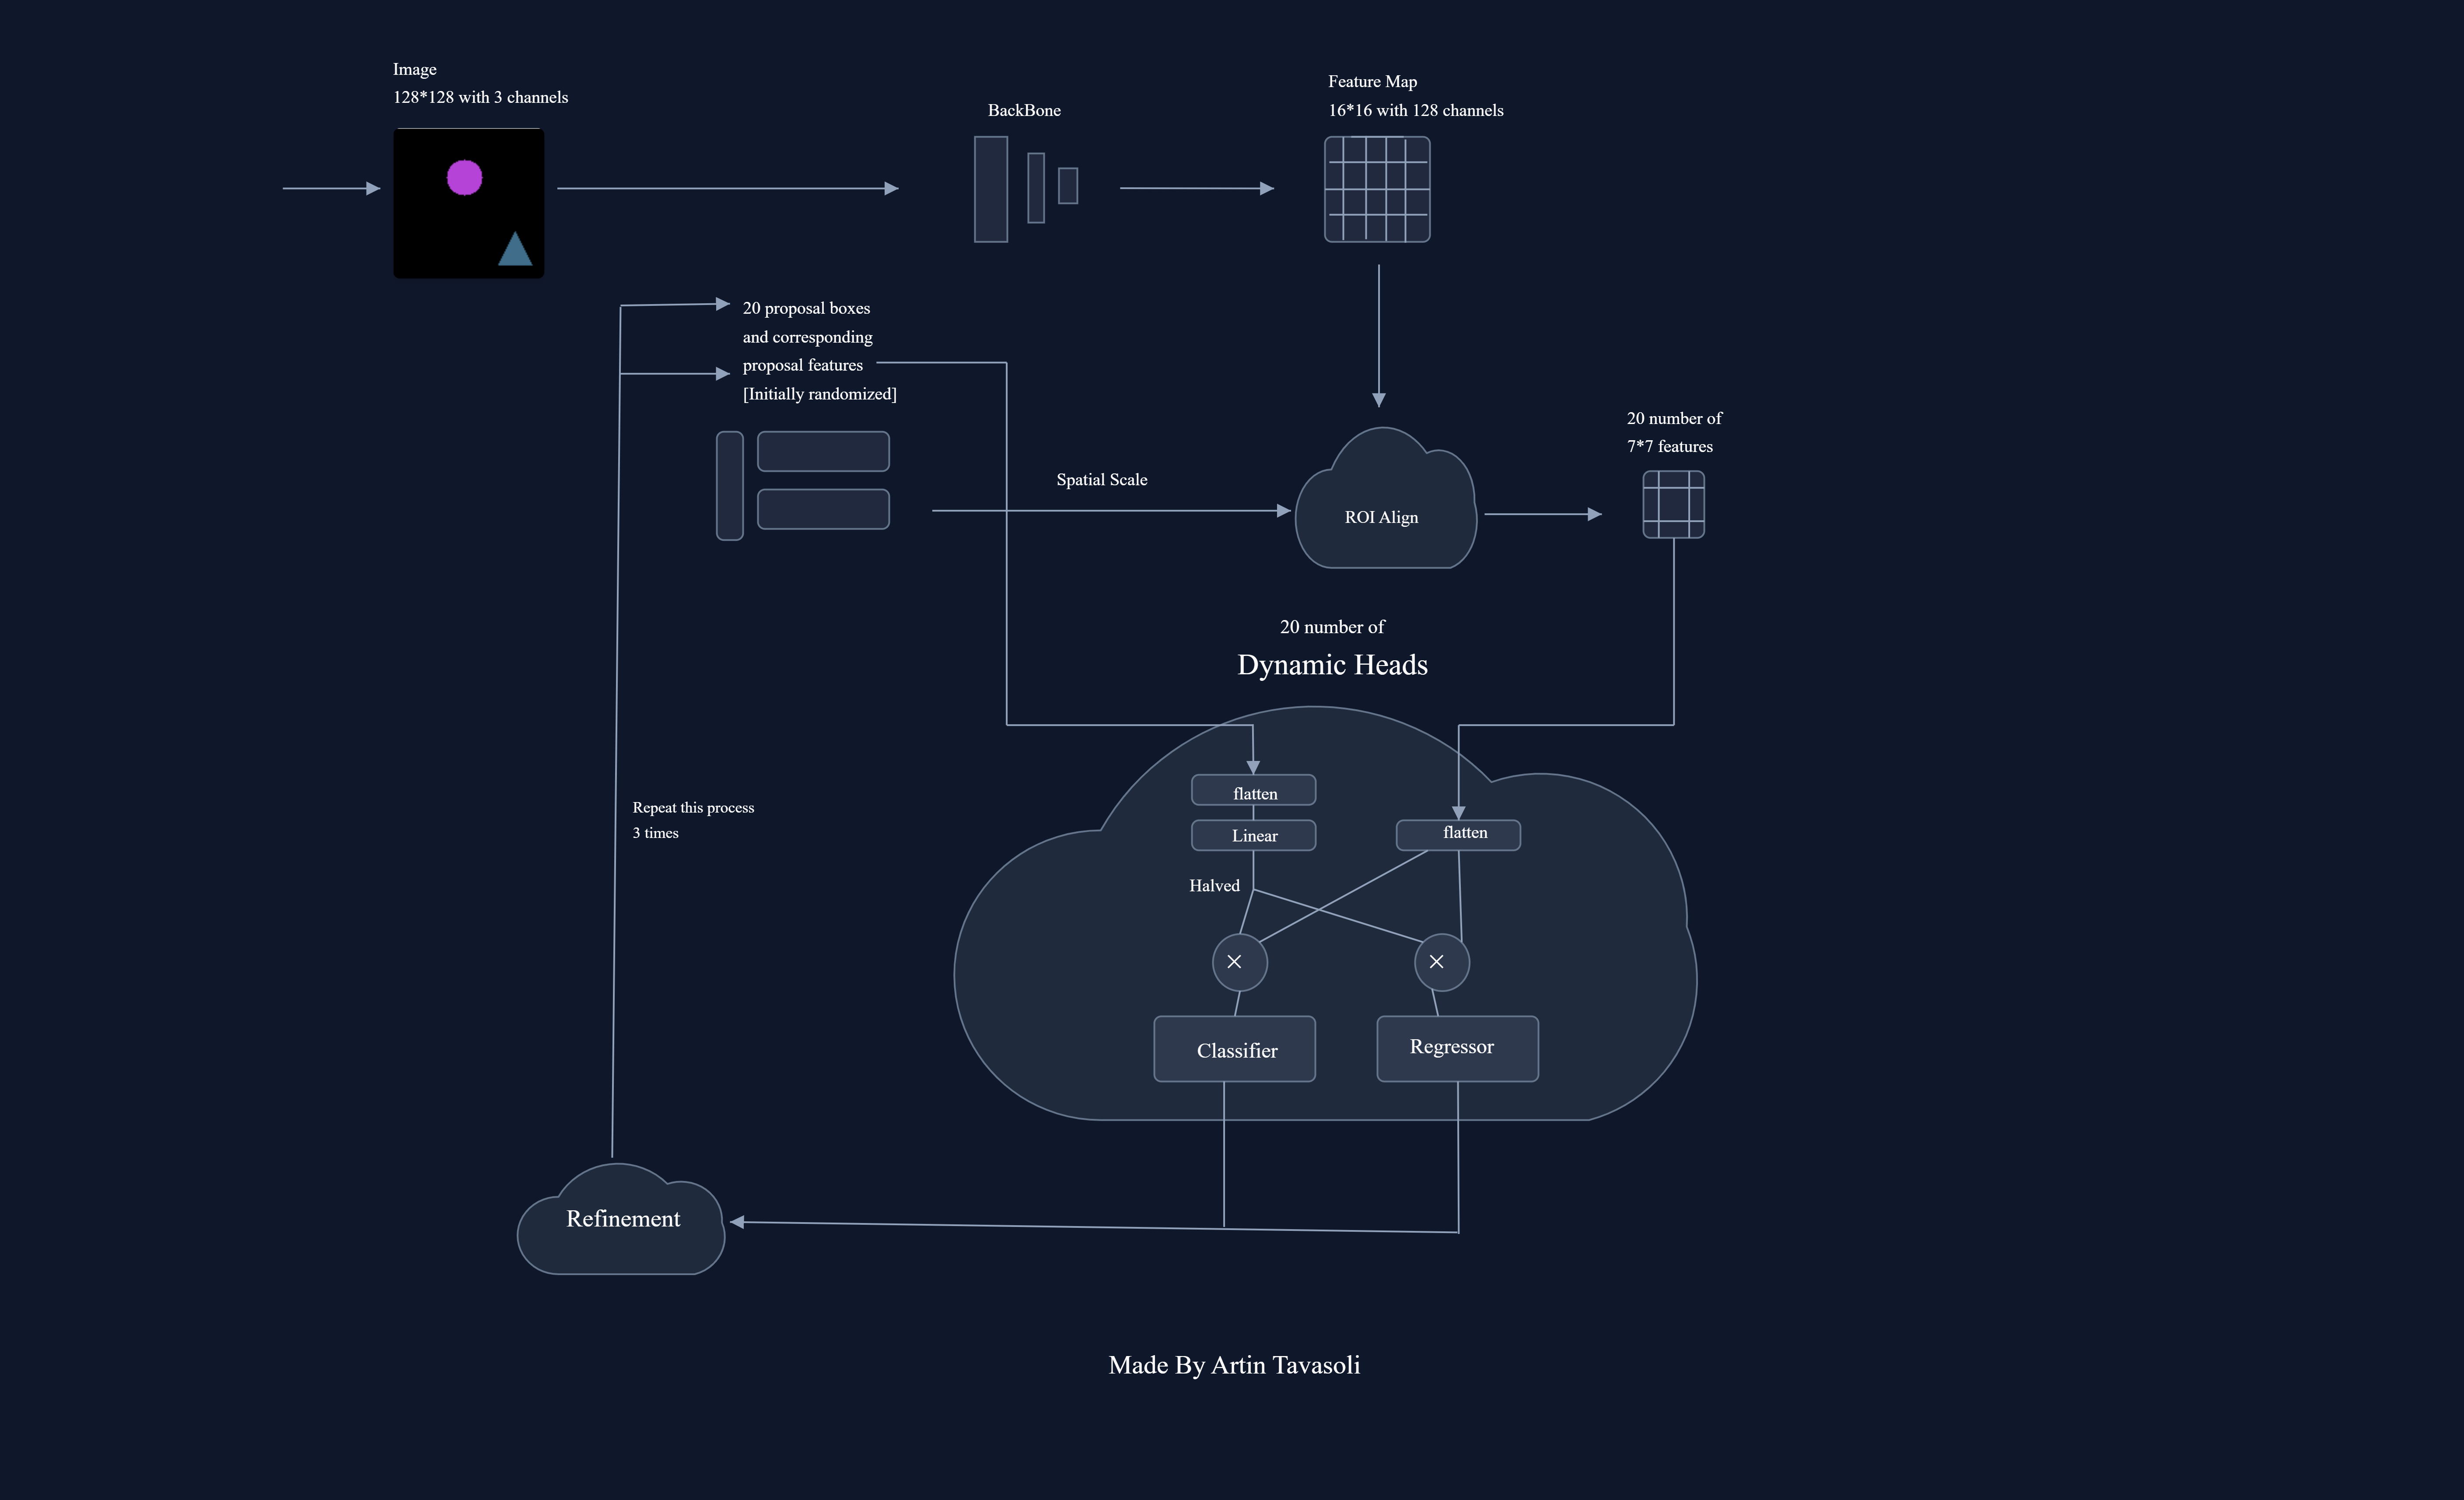

In [1]:
from IPython.display import Image, display

img_path = 'Model-Overview.png'

display(Image(filename=img_path))

**libraries**

In [1]:
import random
import numpy as np
import torch
import os
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transform
import torch.nn as nn
import torchvision.ops as ops
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment
import torchvision.ops as ops
import torch.optim as optim
from torchmetrics.detection.mean_ap import MeanAveragePrecision




**set seed**

we don't want difference results when we run the code multiple times, so we set seed so that the randomness doesn't change

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

**Generating Dataset**

- using np.zeros we create a black image (background)
- then we pick a random number of shapes (between 1,3)
- pick a random type of shape for each one (1:circle, 2:rectangle, 3:traingle) and random coordinates/color/size
- using draw_shape function which uses cv2, we draw these shapes onto our background
- each image has a list of targets corrosponding to it which is a dictionary of boxes and labels (for example in image #1, we have 2 boxes and a label for each one, for example 1 ,2 meaning a circle and a rectangle)
- Now we do these steps for num_of_images times and in the end return images , targets
- example of our data: images[0] has targets['boxes'][0] is the first box in the image and targets['labels'][0] is the corrosponding label to that box (for example 1 meaning circle)  

In [3]:
def generate_random_color():
    return tuple(np.random.randint(50, 256, size=3).tolist())

def draw_shape(img, shape_type, x, y, size, color):
    
    if shape_type == 1:
        center = (x + size // 2, y + size // 2)
        radius = size // 2
        cv2.circle(img, center, radius, color, -1)
        
    elif shape_type == 2:
        cv2.rectangle(img, (x, y), (x + size, y + size), color, -1)
        
    elif shape_type == 3:
        a = (x + size // 2, y)
        b = (x, y + size)
        c = (x + size, y + size)
        triangle = np.array([a, b, c])
        cv2.drawContours(img, [triangle], 0, color, -1)
        
    return img

def generate_toy_dataset(num_samples=1000, img_size=128):
    images = []
    targets = []
    
    for _ in range(num_samples):
        blank_img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        
        num_shapes = random.randint(1, 3)
        
        boxes = []
        labels = []
        
        for _ in range(num_shapes):
            shape_type = random.randint(1, 3)
                
            size = random.randint(20, 40)
            x = random.randint(0, img_size - size)
            y = random.randint(0, img_size - size)
            color = generate_random_color()
            
            img_with_shape = draw_shape(blank_img, shape_type, x, y, size, color)
            
            boxes.append([x, y, size, size])
            labels.append(shape_type)
            
        images.append(img_with_shape)
        targets.append({
            "boxes": boxes,
            "labels": labels
        })
        
    return images, targets

def visualize_samples(images, targets, num_samples=5):
    indices = random.sample(range(len(images)), num_samples)
    class_names = {1: 'circle', 2: 'square', 3: 'triangle'}
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    if num_samples == 1:
        axes = [axes]
        
    for ax, idx in zip(axes, indices):
        img = images[idx].copy()
        target = targets[idx]
        
        for box, label in zip(target['boxes'], target['labels']):
            x, y, w, h = box
            cv2.rectangle(img, (x, y), (x + w, y + h), (255, 255, 255), 1)
            text = class_names[label]
            cv2.putText(img, text, (x, max(10, y - 5)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 255, 255), 1)
            
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

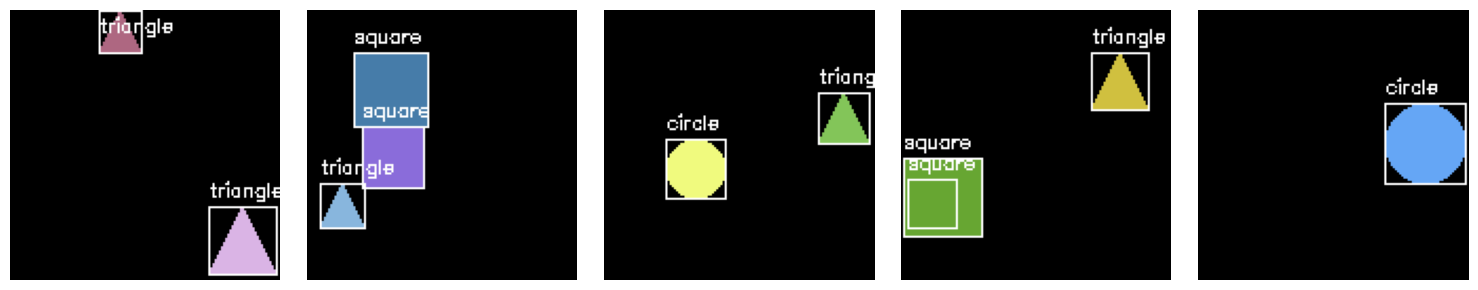

In [4]:
images, targets = generate_toy_dataset(num_samples=1000, img_size=128)
visualize_samples(images, targets, num_samples=5)

**understanding data shapes**

In [5]:
print('each image shape is: ', images[0].shape)
boxes = targets[0]['boxes']
labels = targets[0]['labels']
print('boxes:', boxes)
print('labels', labels)

each image shape is:  (128, 128, 3)
boxes: [[94, 35, 20, 20], [17, 94, 27, 27], [11, 75, 37, 37]]
labels [1, 1, 1]


**creating dataset**

- we covert images and targets to tensors (and by doing so the values normalize)
- also we changed boxes format (instead of [x_min, y_min, w, h] we save [x_min, y_min, x_max, y_max])

**creating dataloader**
  
- stack images becasue each image size is the same
- but targets differ, for example one image can have 3 shapes in it and other 4 so we keep them as a list of dictionaries.


In [6]:
class ObjectDetectionDataset(Dataset):
    def __init__(self, images, targets):
        self.images = images
        self.targets = targets
        self.transform = transform.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        target = self.targets[idx]
        
        img_tensor = self.transform(img)
        
        img_size=128
        formatted_boxes = []
        for box in target["boxes"]:
            x, y, w, h = box
            x_min = x / img_size
            y_min = y / img_size
            x_max = (x + w) / img_size
            y_max =  (y + h) / img_size
            formatted_boxes.append([x_min, y_min, x_max,y_max])
            
        target_tensor = {
            "boxes": torch.tensor(formatted_boxes, dtype=torch.float32),
            "labels": torch.tensor(target["labels"], dtype=torch.int64)
        }
        
        return img_tensor, target_tensor

def collate(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    
    images = torch.stack(images, dim=0)
    
    return images, targets



**test and train split**

In [7]:
def get_dataloaders(images, targets, batch_size=16, train_split=900):
    train_images = images[:train_split]
    train_targets = targets[:train_split]
    
    test_images = images[train_split:]
    test_targets = targets[train_split:]
    
    train_dataset = ObjectDetectionDataset(train_images, train_targets)
    test_dataset = ObjectDetectionDataset(test_images, test_targets)
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        collate_fn=collate
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=collate
    )
    
    return train_loader, test_loader
    
train_dataloader, test_dataloader = get_dataloaders(images, targets, batch_size=16, train_split=900)

In [8]:
for images, targets in train_dataloader:
    print("Images Tensor Shape:", images.shape)
    print("Images Data Type:", images.dtype)
    
    print("\nLength of Targets List:", len(targets))
    
    print("\nFirst Target in the Batch:")
    print("Boxes Tensor:")
    print(targets[0]['boxes'])
    print("Labels Tensor:")
    print(targets[0]['labels'])
    
    break

Images Tensor Shape: torch.Size([16, 3, 128, 128])
Images Data Type: torch.float32

Length of Targets List: 16

First Target in the Batch:
Boxes Tensor:
tensor([[0.2891, 0.0312, 0.5000, 0.2422],
        [0.5312, 0.2812, 0.7422, 0.4922],
        [0.5625, 0.4922, 0.8281, 0.7578]])
Labels Tensor:
tensor([1, 2, 1])


**Backbone**
- input: [Batch, 3, 128, 128]
- Block 1: increase channel depth to 32 and stride = 2 so [Batch, 32, 64, 64]
- Block 2: increase channel depth to 64 and stride = 2 so [Batch, 64, 32, 32]
- Block 3: increase channel depth to 128 and stride = 2 so [Batch, 128, 16, 16]
- After each Convolution layer, Batch Normalization was used to normalize outputs for more training stability.

In [9]:
class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

**DynamicHead**

* The module flattens the proposal features and passes them through A linear projection(into a high-dimensional vector). The resulting dynamic tensor is chunked into `param1` and `param2`, representing the weights for the two customized transformation steps .

* Instead of standard 2D convolutions, the network uses Batch Matrix Multiplication (`torch.bmm`) to apply `param1` and `param2` directly to the RoI features. Each RoI feature interacts strictly with the parameters generated from its paired proposal feature, followed by Layer Normalization and ReLU.
After which, we flatten them and passed them through a liner layer to get  `refined_features`

* The head predicts class probabilities using a single linear projection (`cls_layer`) and predicts coordinate refinements (deltas) using a 3-layer Multi-Layer Perceptron (MLP) equipped with ReLU activations (`reg_layer`).

* The network outputs `cls_logits` for classification, `box_deltas` for bounding box refinement, and the updated `refined_features`. In the iterative architecture of Sparse R-CNN, these `refined_features` will act as the new proposal features for the next refinement stage.

In [10]:
class DynamicHead(nn.Module):
    def __init__(self, in_channels=128, roi_size=7, num_classes=4):
        super().__init__()
        self.in_channels = in_channels
        self.roi_size = roi_size
        self.num_classes = num_classes
        
        self.hidden_dim = in_channels // 4 

        self.project_proposal_features = nn.Linear(in_channels, 2 * in_channels * self.hidden_dim)
        
        self.norm1 = nn.LayerNorm(self.hidden_dim)
        self.norm2 = nn.LayerNorm(in_channels)
        self.refine_features = nn.Linear(roi_size * roi_size * in_channels, in_channels)
        self.cls_layer = nn.Linear(in_channels, num_classes)
        
        self.reg_layer = nn.Sequential(
            nn.Linear(in_channels, in_channels),
            nn.ReLU(),
            nn.Linear(in_channels, in_channels),
            nn.ReLU(),
            nn.Linear(in_channels, 4)
        )
        
        nn.init.constant_(self.reg_layer[-1].weight, 0)
        nn.init.constant_(self.reg_layer[-1].bias, 0)

    def forward(self, roi_features, proposal_features):

        B, N, C = proposal_features.shape
        
        proposal_features_flat = proposal_features.view(B * N, C)
        params = self.project_proposal_features(proposal_features_flat)
        split_point = C * self.hidden_dim
        param1 = params[:, :split_point].view(B * N, C, self.hidden_dim) 
        param2 = params[:, split_point:].view(B * N, self.hidden_dim, C) 
        
        roi_features_flat = roi_features.view(B * N, C, self.roi_size * self.roi_size).permute(0, 2, 1)

        
        x = torch.bmm(roi_features_flat, param1)
        x = F.relu(self.norm1(x))
        x = torch.bmm(x, param2)
        x = F.relu(self.norm2(x))
        x = x.flatten(1) 
        
        refined_features = self.refine_features(x)
        refined_features = refined_features.view(B, N, C) 
        
        cls_logits = self.cls_layer(refined_features)
        cls_logits = cls_logits.view(B, N, self.num_classes)
        
        box_deltas = self.reg_layer(refined_features) 
        box_deltas = box_deltas.view(B, N, 4)
        
        return cls_logits, box_deltas, refined_features

**Sparse R-CNN** 


* Instead of relying on a Region Proposal Network (RPN) to generate hundreds of thousands of candidates, the model initializes a small, fixed set (here, `num_proposals=20`) of $N \times 4$ coordinates. These are initialized with random values bounded between $0$ and $1$ and wrapped in `nn.Parameter` so they can be optimized via back-propagation during training.

* The globally learned `proposal_boxes` and `proposal_features` act as dataset-level statistics. During the forward pass, they are cloned and expanded to match the batch size `B`, providing the initial guesses for every image in the batch.


* The network loops through `self.num_stages` (set to 3). In each stage, the predictions are progressively refined.


* For the current set of boxes, the model uses `torchvision.ops.roi_align` to pool fixed-size spatial features ($7 \times 7$) directly from the backbone's feature map.


* The extracted `roi_feats` and current `prop_features` are fed into the `DynamicHead`. The head returns the classification logits, the coordinate refinements (`box_deltas`), and the updated proposal features for the next stage.


* The predicted `box_deltas` are added to the current boxes. To ensure the network does not crash due to invalid coordinates, the updated boxes are immediately clamped to the $[0.0, 1.0]$ range. Additionally, a strict geometric constraint ($x_1 < x_2$ and $y_1 < y_2$) is enforced using a small epsilon (`eps = 1e-3`).


In [11]:
class SparseRCNN(nn.Module):
    def __init__(self, num_proposals=20, num_classes=4):
        super().__init__()
        self.num_proposals = num_proposals
        self.num_stages = 3
        
        self.spatial_scale = 16.0
        
        self.backbone = Backbone() 
        self.head = DynamicHead(in_channels=128, roi_size=7, num_classes=num_classes)
        
        init_x = torch.rand(num_proposals) * 0.6 + 0.1  
        init_y = torch.rand(num_proposals) * 0.6 + 0.1
        init_w = torch.rand(num_proposals) * 0.2 + 0.1 
        init_h = torch.rand(num_proposals) * 0.2 + 0.1
        
        init_boxes = torch.stack([init_x, init_y, init_x + init_w, init_y + init_h], dim=1)
        self.proposal_boxes = nn.Parameter(init_boxes)
        
        self.proposal_features = nn.Parameter(torch.randn(num_proposals, 128))

    def forward(self, images):
        B = images.size(0)
        device = images.device
        
        features = self.backbone(images)
        
        # we coppied the proposals for each image of the batch
        boxes = self.proposal_boxes.unsqueeze(0).expand(B, -1, -1).clone()
        prop_features = self.proposal_features.unsqueeze(0).expand(B, -1, -1).clone()
        
        all_cls_logits = []
        all_boxes = []
        
        for stage in range(self.num_stages):
            roi_boxes = []
            for i in range(B):
                batch_idx = torch.full((self.num_proposals, 1), i, dtype=boxes.dtype, device=device)
                roi_box = torch.cat([batch_idx, boxes[i]], dim=1)
                roi_boxes.append(roi_box)
            
            roi_boxes = torch.cat(roi_boxes, dim=0)
            
            roi_feats = ops.roi_align(features, roi_boxes, output_size=(7, 7), 
                                      spatial_scale=self.spatial_scale, aligned=True)
            
            cls_logits, box_deltas, prop_features = self.head(roi_feats, prop_features)
            
            new_boxes = boxes + box_deltas
            
            x1 = torch.clamp(new_boxes[:, :, 0], min=0.0, max=1.0)
            y1 = torch.clamp(new_boxes[:, :, 1], min=0.0, max=1.0)
            x2 = torch.clamp(new_boxes[:, :, 2], min=0.0, max=1.0)
            y2 = torch.clamp(new_boxes[:, :, 3], min=0.0, max=1.0)
            
            eps = 1e-3
            x1_safe = torch.min(x1, x2 - eps)
            x2_safe = torch.max(x2, x1 + eps)
            y1_safe = torch.min(y1, y2 - eps)
            y2_safe = torch.max(y2, y1 + eps)
            
            boxes = torch.stack([x1_safe, y1_safe, x2_safe, y2_safe], dim=-1)
            
            all_cls_logits.append(cls_logits)
            all_boxes.append(boxes)
            
        return all_cls_logits, all_boxes

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SparseRCNN(num_proposals=20, num_classes=4).to(device)

images_batch, targets_batch = next(iter(train_dataloader))
images_batch = images_batch.to(device)

all_cls_logits, all_boxes = model(images_batch)

print(f"Number of stages computed: {len(all_boxes)}")
print(f"Shape of logits in final stage: {all_cls_logits[-1].shape}")
print(f"Shape of boxes in final stage: {all_boxes[-1].shape}")

Number of stages computed: 3
Shape of logits in final stage: torch.Size([16, 20, 4])
Shape of boxes in final stage: torch.Size([16, 20, 4])


**Hungarian Matching**

Instead of relying on heuristic, many-to-one label assignments (e.g., assigning multiple dense anchors to a single ground truth based on IoU thresholds), this matcher enforces a strict one-to-one assignment between the network's predictions and the actual ground truth objects.

**Classification Cost** The raw logits are passed through a `sigmoid()` activation to extract class probabilities. The cost is computed as the negative probability of the true class (higher probability results in a lower cost).

**L1 Distance Cost** Computes the pairwise absolute distances between the center coordinates, width, and height of the flattened predicted boxes and ground truth boxes.


**Generalized IoU Cost** Computes the negative Generalized IoU (GIoU). Unlike standard L1 distance, GIoU is scale-invariant and penalizes boxes that do not overlap well with the ground truth.

**Total Cost** The individual costs are multiplied by their respective coefficients and summed to form the final cost matrix.

`scipy.optimize.linear_sum_assignment` applies the Hungarian algorithm to solve the linear assignment problem. It finds the optimal combination of prediction-to-target pairs that yields the lowest possible overall matching cost for that specific image.
The method returns a list of matched index tuples `(prediction_index, target_index)` which are subsequently used by the `SparseRCNNCriterion` to calculate the actual loss for backpropagation.

In [16]:
class HungarianMatcher:
    def __init__(self, weight_class=2.0, weight_bbox=5.0, weight_giou=2.0):
        self.weight_class = weight_class
        self.weight_bbox = weight_bbox
        self.weight_giou = weight_giou



    @torch.no_grad()
    def __call__(self, pred_logits, pred_boxes, targets):
        bs, num_queries = pred_logits.shape[:2]

        probs = pred_logits.flatten(0, 1).sigmoid() 
        out_bbox = pred_boxes.flatten(0, 1)

        cost_class = -probs[:, torch.cat([v["labels"] for v in targets])]

        target_bbox = torch.cat([v["boxes"] for v in targets])
        cost_bbox = torch.cdist(out_bbox, target_bbox, p=1)        
        cost_giou = -ops.generalized_box_iou(out_bbox, target_bbox)

        total_cost = self.weight_bbox * cost_bbox + self.weight_class * cost_class + self.weight_giou * cost_giou
        
        total_cost = total_cost.view(bs, num_queries, -1).cpu()

        sizes = [len(v["boxes"]) for v in targets]
        
        indices = [linear_sum_assignment(c[i]) for i, c in enumerate(total_cost.split(sizes, -1))]

        return [(torch.as_tensor(i, dtype=torch.int64), torch.as_tensor(j, dtype=torch.int64)) for i, j in indices]



**Loss Functions**

The total loss for a matched pair is a weighted linear combination of the classification loss and two bounding box regression losses:

$$\mathcal{L} = \lambda_{cls} \mathcal{L}_{cls} + \lambda_{L1} \mathcal{L}_{L1} + \lambda_{giou} \mathcal{L}_{giou}$$

Where the standard coefficients are configured as $\lambda_{cls} = 2.0$, $\lambda_{L1} = 5.0$, and $\lambda_{giou} = 2.0$.

**Classification Loss**

Because the vast majority of the initial proposals will match with the "background" (no object), there is a severe class imbalance. To prevent the background class from dominating the loss gradients, we used Focal Loss  rather than standard Cross-Entropy.

$$FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

* **$p_t$**: The model's estimated probability for the target class (computed using the `sigmoid` activation).
* **$\gamma$ (Focusing Parameter)**: Set to 2.0. It smoothly down-weights the penalty for easy examples (where $p_t$ is close to 1), forcing the model to focus on hard, misclassified examples.
* **$\alpha_t$ (Balancing Factor)**: Set to 0.25. It balances the importance of positive and negative samples.


#### 2. Bounding Box Regression Loss (`loss_boxes`)

The model evaluates only the proposals that were successfully matched to a ground truth object by the Hungarian Matcher.

**A. L1 Loss**
This loss calculates the absolute pixel-wise distance between the predicted box coordinates and the ground truth.

$$\mathcal{L}_{L1} = \frac{1}{N} \sum_{i=1}^{N} |b_{i}^{pred} - b_{i}^{gt}|$$

While L1 is effective for raw coordinate adjustments, it is not scale-invariant (a small pixel error on a large box is penalized the same as a small error on a tiny box).

**B. Generalized Intersection over Union (GIoU) Loss:**
To solve the scale-variance issue of L1, GIoU is added.

$$\mathcal{L}_{giou} = 1 - \left( IoU - \frac{|C \setminus (A \cup B)|}{|C|} \right)$$

* **$A$ and $B$**: The predicted box and the ground truth box.
* **$C$**: The smallest enclosing convex hull (the smallest possible box that completely covers both $A$ and $B$).
* If the boxes do not intersect ($IoU = 0$), the ratio in the formula acts as a penalty that pushes the predicted box towards the target.

During the forward pass, the criterion receives the predictions for a specific iteration `stage_idx`.

1. Matching: It first calls `self.matcher` to find the optimal permutations (`indices`) that link predictions to ground truths.
2. Loss Computation: It calculates `loss_labels` and `loss_boxes` exclusively using these matched indices.
3. Weighting: It scales the individual loss components by the static `stage_weights` dictionary (`2.0`, `5.0`, `2.0`).

In [19]:
def focal_loss(inputs, targets, alpha: float = 0.25, gamma: float = 2.0):
    prob = inputs.sigmoid()
    p_t = prob * targets + (1 - prob) * (1 - targets)
    # instead of log(p_t), with this p_t definition it's equal to cross entropy loss, so we just use the built in pytorch function (it handles NaN values.)
    ce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
    alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
    loss = alpha_t * ce_loss * ((1 - p_t) ** gamma)
        
    return loss.sum()

class SparseRCNNCriterion(nn.Module):
    def __init__(self, matcher, num_classes=4):
        super().__init__()
        self.matcher = matcher
        self.num_classes = num_classes
        
        self.weight_dict = {
            'loss_ce': 2.0,
            'loss_bbox': 5.0,
            'loss_giou': 2.0
        }

    def loss_labels(self, outputs, targets, indices):
            src_logits = outputs['pred_logits'] 
            idx = self.get_perm_idx(indices)
            target_classes_o = torch.cat([t["labels"][J] for t, (_, J) in zip(targets, indices)])
            target_classes = torch.zeros_like(src_logits)
            target_classes[idx[0], idx[1], target_classes_o] = 1.0
            
            loss_ce = focal_loss(src_logits, target_classes)
            num_pos = max(1, target_classes_o.numel())
            loss_ce = loss_ce.sum() / num_pos
            
            return {'loss_ce': loss_ce}

    def get_perm_idx(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx
            
    def loss_boxes(self, outputs, targets, indices):
        idx = self.get_perm_idx(indices)
        
        src_boxes = outputs['pred_boxes'][idx[0], idx[1]]
        target_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(targets, indices)], dim=0)
        
        loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction='mean')
        
        loss_giou = 1 - torch.diag(ops.generalized_box_iou(src_boxes, target_boxes)).mean()
        
        return {'loss_bbox': loss_bbox, 'loss_giou': loss_giou}



    def forward(self, outputs, targets, stage_idx):

        indices = self.matcher(outputs['pred_logits'], outputs['pred_boxes'], targets)
        
        losses = {}
        losses.update(self.loss_labels(outputs, targets, indices))
        losses.update(self.loss_boxes(outputs, targets, indices))
        
        stage_weights = {
            'loss_ce': 2.0,
            'loss_bbox': 5.0,
            'loss_giou': 2.0
        }
            
        stage_losses = {}
        for k, v in losses.items():
            stage_losses[f'{k}_stage_{stage_idx}'] = v * stage_weights[k]
            
        return stage_losses

**Training**

finally :)

Epoch [1/50] | LR: 0.000500 | Train Loss: 7.2925 | Test mAP: 0.1876
Epoch [2/50] | LR: 0.000499 | Train Loss: 4.0325 | Test mAP: 0.4624
Epoch [3/50] | LR: 0.000498 | Train Loss: 3.2983 | Test mAP: 0.6052
Epoch [4/50] | LR: 0.000497 | Train Loss: 2.9578 | Test mAP: 0.6694
Epoch [5/50] | LR: 0.000495 | Train Loss: 2.6877 | Test mAP: 0.6922
Epoch [6/50] | LR: 0.000493 | Train Loss: 2.5458 | Test mAP: 0.6553
Epoch [7/50] | LR: 0.000490 | Train Loss: 2.4784 | Test mAP: 0.6350
Epoch [8/50] | LR: 0.000488 | Train Loss: 2.4084 | Test mAP: 0.7612
Epoch [9/50] | LR: 0.000484 | Train Loss: 2.3219 | Test mAP: 0.7707
Epoch [10/50] | LR: 0.000481 | Train Loss: 2.1876 | Test mAP: 0.7872
last batch details
  loss_ce_stage_0: 0.3705
  loss_bbox_stage_0: 0.0798
  loss_giou_stage_0: 0.4466
  loss_ce_stage_1: 0.1797
  loss_bbox_stage_1: 0.0317
  loss_giou_stage_1: 0.2024
  loss_ce_stage_2: 0.1801
  loss_bbox_stage_2: 0.0229
  loss_giou_stage_2: 0.1441
----------------------------------------
Epoch [11/50]

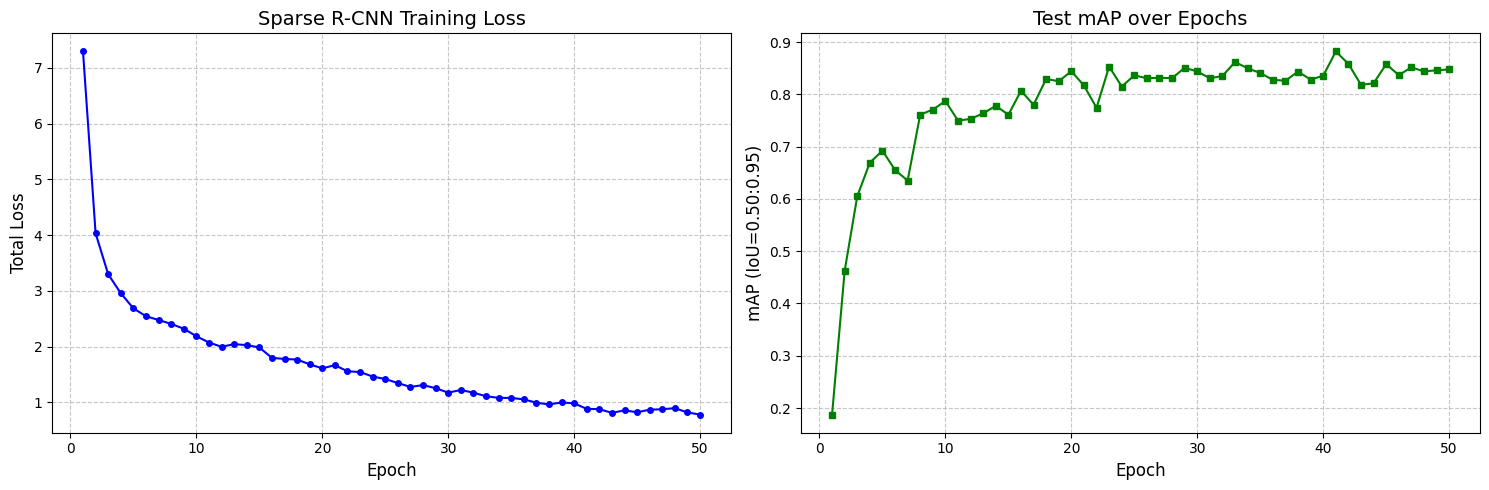

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SparseRCNN(num_proposals=20, num_classes=4).to(device)

initial_boxes = model.proposal_boxes.detach().cpu().clone() * 128.0

matcher = HungarianMatcher()
criterion = SparseRCNNCriterion(matcher, num_classes=4).to(device)

optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

num_epochs = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=3e-4)

epoch_losses = []
epoch_maps = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    
    for batch_idx, (images, targets) in enumerate(train_dataloader):
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        all_cls_logits, all_boxes = model(images)
        
        total_loss = 0
        all_losses_log = {}
        
        for stage_idx in range(model.num_stages):
            outputs = {
                'pred_logits': all_cls_logits[stage_idx],
                'pred_boxes': all_boxes[stage_idx]
            }
            
            stage_losses = criterion(outputs, targets, stage_idx)
            for loss_val in stage_losses.values():
                total_loss += loss_val
                
            all_losses_log.update(stage_losses)
            
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += total_loss.item()
    
    scheduler.step()
    avg_epoch_loss = running_loss / len(train_dataloader)
    epoch_losses.append(avg_epoch_loss)
    

    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
    
    with torch.no_grad():
        for test_images, test_targets in test_dataloader:
            test_images = test_images.to(device)
            test_targets = [{k: v.to(device) for k, v in t.items()} for t in test_targets]
            
            all_cls_logits, all_boxes = model(test_images)
            last_logits = all_cls_logits[-1]
            last_boxes = all_boxes[-1]
            
            probs = last_logits.sigmoid()
            scores, labels = torch.max(probs, dim=-1)
            
            preds_for_metric = []
            targets_for_metric = []
            
            for i in range(test_images.size(0)):
                valid_mask = labels[i] > 0
                pred_boxes_scaled = last_boxes[i][valid_mask] * 128.0
                
                preds_for_metric.append({
                    "boxes": pred_boxes_scaled.cpu(),
                    "scores": scores[i][valid_mask].cpu(),
                    "labels": labels[i][valid_mask].cpu()
                })
                
                target_boxes_scaled = test_targets[i]["boxes"] * 128.0
                targets_for_metric.append({
                    "boxes": target_boxes_scaled.cpu(),
                    "labels": test_targets[i]["labels"].cpu()
                })
                
            metric.update(preds_for_metric, targets_for_metric)
            
    map_results = metric.compute()
    current_map = map_results['map'].item()
    epoch_maps.append(current_map)
 
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.6f} | Train Loss: {avg_epoch_loss:.4f} | Test mAP: {current_map:.4f}")
    
    if (epoch + 1) % 10 == 0:
        print('last batch details')
        for loss_name, loss_value in all_losses_log.items():
            print(f"  {loss_name}: {loss_value.item():.4f}")
        print("-" * 40)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-', color='b', markersize=4)
ax1.set_title('Sparse R-CNN Training Loss', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Total Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(range(1, num_epochs + 1), epoch_maps, marker='s', linestyle='-', color='g', markersize=4)
ax2.set_title('Test mAP over Epochs', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('mAP (IoU=0.50:0.95)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

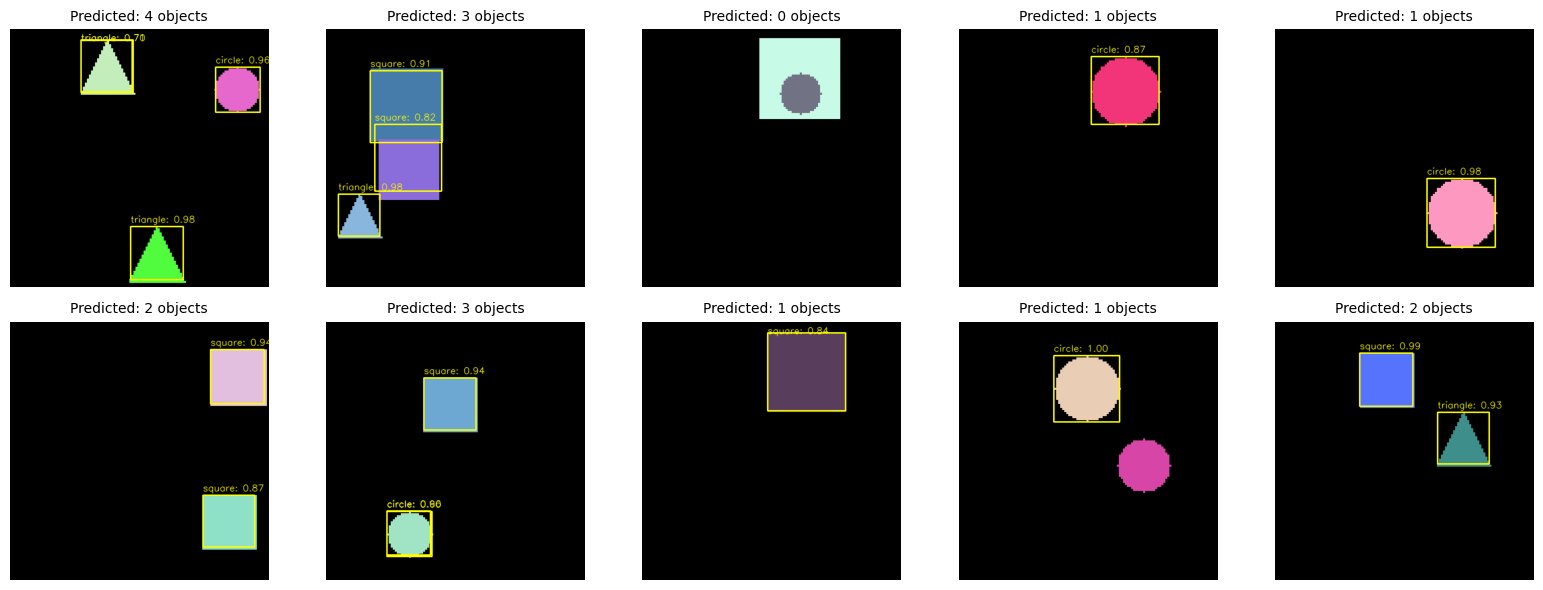

mAP (IoU=0.50:0.95): 0.8476


In [21]:
def evaluate_and_visualize(model, test_dataloader, device, score_threshold=0.3, num_samples=10):
    model.eval()
    
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
    
    class_names = {1: 'circle', 2: 'square', 3: 'triangle'}
    samples_shown = 0
    
    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    axes = axes.flatten()
    
    with torch.no_grad():
        for images, targets in test_dataloader:
            images = images.to(device)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            all_cls_logits, all_boxes = model(images)
            last_logits = all_cls_logits[-1]
            last_boxes = all_boxes[-1]
            
            probs = last_logits.sigmoid()
            scores, labels = torch.max(probs, dim=-1)
            
            preds_for_metric = []
            targets_for_metric = []
            
            for i in range(images.size(0)):
                valid_mask = labels[i] > 0
                pred_boxes_scaled = last_boxes[i][valid_mask] * 128.0
                
                preds_for_metric.append({
                    "boxes": pred_boxes_scaled.cpu(),
                    "scores": scores[i][valid_mask].cpu(),
                    "labels": labels[i][valid_mask].cpu()
                })
                
                target_boxes_scaled = targets[i]["boxes"] * 128.0
                targets_for_metric.append({
                    "boxes": target_boxes_scaled.cpu(),
                    "labels": targets[i]["labels"].cpu()
                })
                
                if samples_shown < num_samples:
                    draw_mask = (scores[i] > score_threshold) & (labels[i] > 0)
                    draw_boxes = last_boxes[i][draw_mask] * 128.0
                    draw_labels = labels[i][draw_mask]
                    draw_scores = scores[i][draw_mask]
                    
                    img = images[i].cpu().permute(1, 2, 0).numpy()
                    img = (img * 255).astype(np.uint8).copy()
                    
                    scale_factor = 4
                    new_size = (img.shape[1] * scale_factor, img.shape[0] * scale_factor)
                    img_hd = cv2.resize(img, new_size, interpolation=cv2.INTER_NEAREST)
                    
                    for box, label, score in zip(draw_boxes, draw_labels, draw_scores):
                        x1, y1, x2, y2 = (box.cpu().numpy() * scale_factor).astype(int)
                        
                        cv2.rectangle(img_hd, (x1, y1), (x2, y2), (0, 255, 255), 2)
                        text = f"{class_names[label.item()]}: {score.item():.2f}"
                        
                        cv2.putText(img_hd, text, (x1, max(25, y1 - 8)), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 1, cv2.LINE_AA)
                    
                    ax = axes[samples_shown]
                    ax.imshow(cv2.cvtColor(img_hd, cv2.COLOR_BGR2RGB))
                    ax.set_title(f"Predicted: {len(draw_boxes)} objects", fontsize=10)
                    ax.axis('off')
                    samples_shown += 1
            
            metric.update(preds_for_metric, targets_for_metric)

    for j in range(samples_shown, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    map_results = metric.compute()
    print(f"mAP (IoU=0.50:0.95): {map_results['map']:.4f}")

evaluate_and_visualize(model, test_dataloader, device, score_threshold=0.3, num_samples=10)

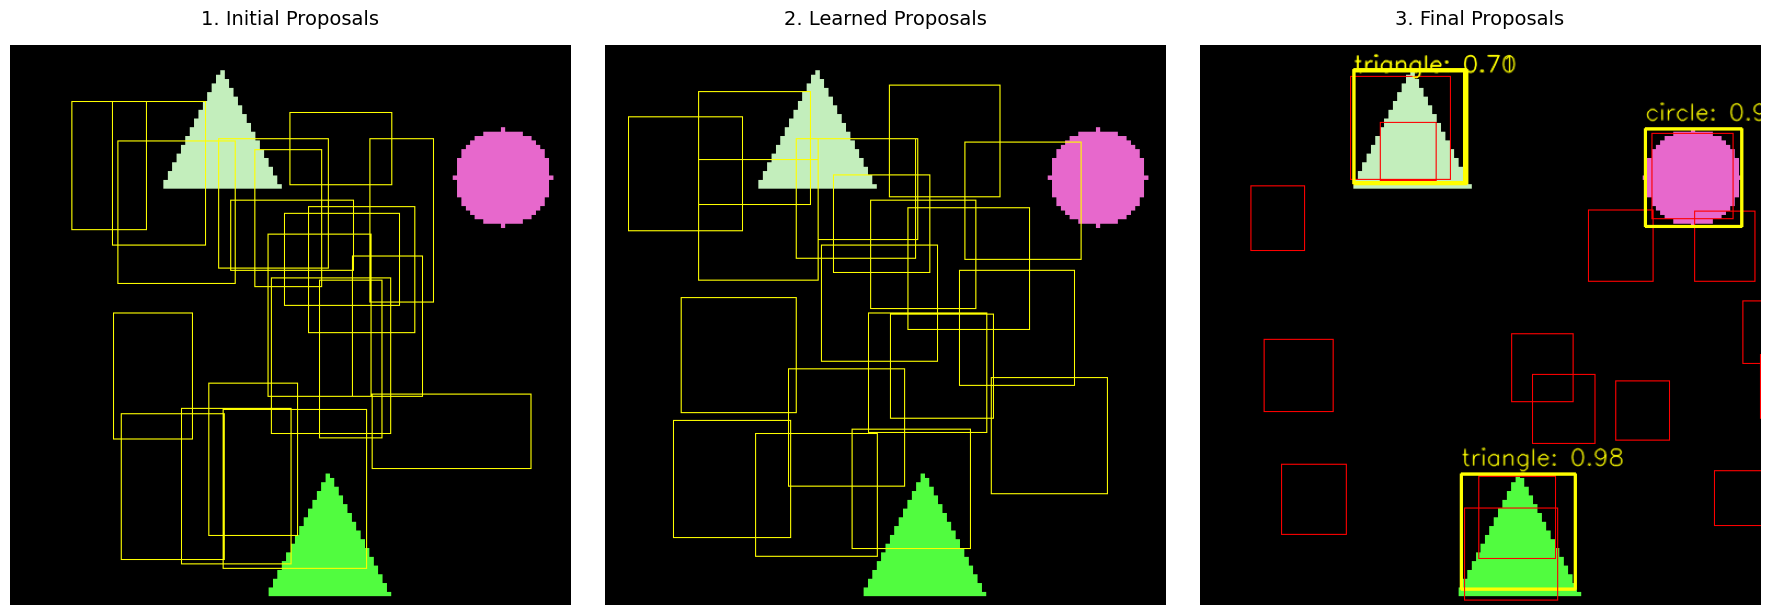

In [23]:
def visualize_proposal_evolution(model, test_dataloader, device, initial_boxes):
    model.eval()
    
    images, targets = next(iter(test_dataloader))
    img_tensor = images[0:1].to(device)
    original_img = images[0].permute(1, 2, 0).numpy()
    original_img = (original_img * 255).astype(np.uint8).copy()
    
    learned_boxes = model.proposal_boxes.detach().cpu() * 128.0
    
    with torch.no_grad():
        all_cls_logits, all_boxes = model(img_tensor)
        final_boxes = all_boxes[-1][0].cpu() * 128.0
        probs = all_cls_logits[-1][0].sigmoid()
        scores, labels = torch.max(probs, dim=-1)
        scores = scores.cpu()
        labels = labels.cpu()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    titles = [
        "1. Initial Proposals", 
        "2. Learned Proposals", 
        "3. Final Proposals"
    ]
    
    boxes_to_draw = [initial_boxes, learned_boxes, final_boxes]
    
    for i, ax in enumerate(axes):
        scale_factor = 4
        new_size = (original_img.shape[1] * scale_factor, original_img.shape[0] * scale_factor)
        img_hd = cv2.resize(original_img, new_size, interpolation=cv2.INTER_NEAREST)
        
        current_boxes = boxes_to_draw[i]
        
        for j, box in enumerate(current_boxes):
            x1, y1, x2, y2 = (box.numpy() * scale_factor).astype(int)
            
            if i < 2:
                color = (0, 255, 255)
                thickness = 1
            else:
                is_confident = (scores[j] > 0.3) and (labels[j] > 0)
                color = (0, 255, 255) if is_confident else (0, 0, 255) 
                thickness = 2 if is_confident else 1
            
            cv2.rectangle(img_hd, (x1, y1), (x2, y2), color, thickness)
            
            if i == 2 and is_confident:
                class_names = {1: 'circle', 2: 'square', 3: 'triangle'}
                lbl = f"{class_names[labels[j].item()]}: {scores[j]:.2f}"
                cv2.putText(img_hd, lbl, (x1, max(25, y1 - 8)), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 1, cv2.LINE_AA)
        
        ax.imshow(cv2.cvtColor(img_hd, cv2.COLOR_BGR2RGB))
        ax.set_title(titles[i], fontsize=14, pad=15)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_proposal_evolution(model, test_dataloader, device, initial_boxes)